In [10]:

## Data Analyst - Exploratory Data Analysis

### Dataset
#CIFAR-10

### Objective
###Perform exploratory and statistical analysis of the CIFAR-10 dataset
####brightness, contrast, distributions, and potential anomalies.

In [11]:
import sys
from pathlib import Path

# Find the project root
current_path = Path.cwd()

if (current_path / "src" / "eda.py").exists():
    PROJECT_ROOT = current_path
elif (current_path.parent / "src" / "eda.py").exists():
    PROJECT_ROOT = current_path.parent
else:
    raise FileNotFoundError("Could not locate the project root.")

# Add project root to Python path
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)

Project root: c:\Users\prithvi\Desktop\999\secure-vision-ai


In [12]:
images, labels = load_training_data()

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)

NameError: name 'load_training_data' is not defined

In [ ]:
overview = dataset_overview(images, labels)

overview_df = pd.DataFrame(
    overview.items(),
    columns=["Metric", "Value"]
)

overview_df

,Metric,Value
0,number_of_images,50000.000000
1,image_height,32.000000
2,image_width,32.000000
3,channels,3.000000
4,number_of_classes,10.000000
5,pixel_minimum,0.000000
6,pixel_maximum,255.000000
7,pixel_mean,120.707565
8,pixel_std,64.150076


In [ ]:
distribution = class_distribution(labels)

distribution

,class_id,class_name,image_count,percentage
0,0,airplane,5000,10.0
1,1,automobile,5000,10.0
2,2,bird,5000,10.0
3,3,cat,5000,10.0
4,4,deer,5000,10.0
5,5,dog,5000,10.0
6,6,frog,5000,10.0
7,7,horse,5000,10.0
8,8,ship,5000,10.0
9,9,truck,5000,10.0


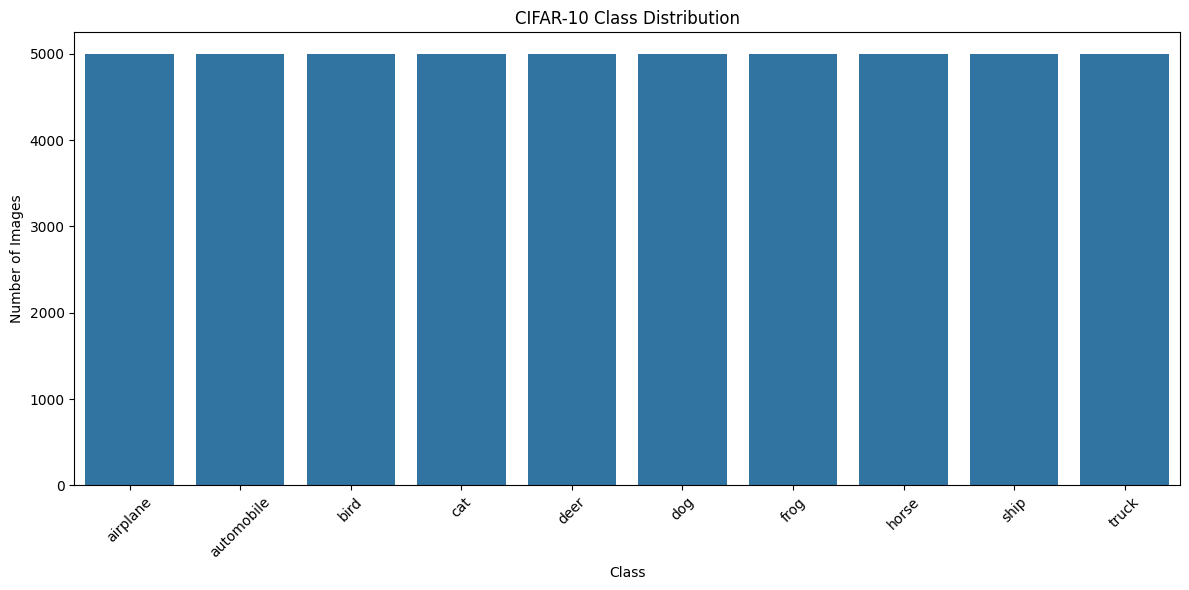

In [ ]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=distribution,
    x="class_name",
    y="image_count"
)

plt.title("CIFAR-10 Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

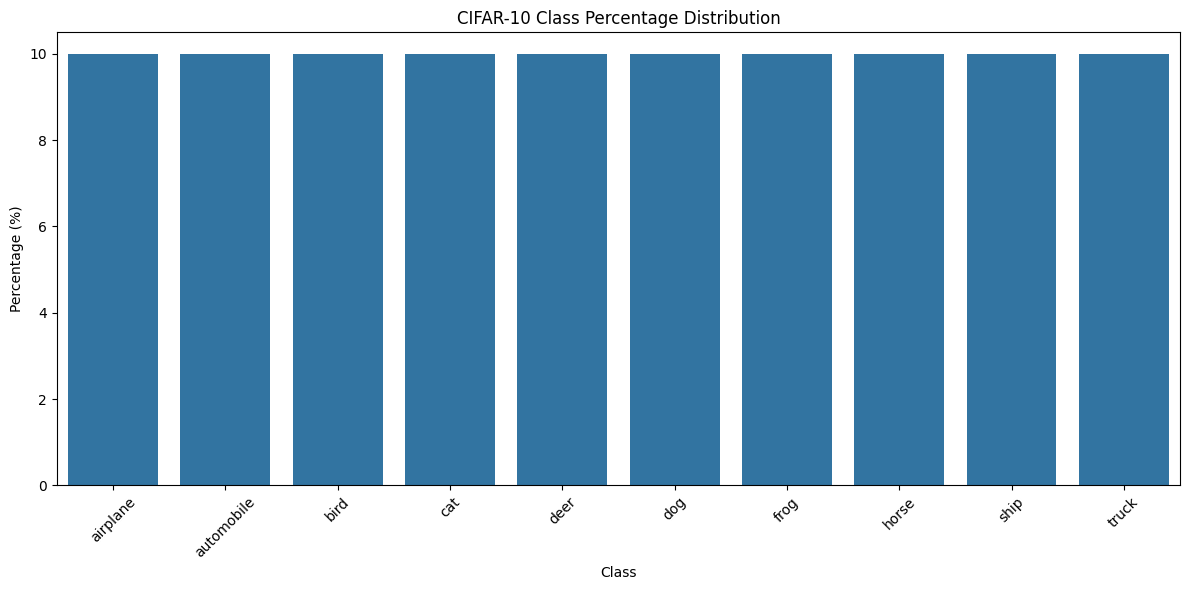

In [ ]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=distribution,
    x="class_name",
    y="percentage"
)

plt.title("CIFAR-10 Class Percentage Distribution")
plt.xlabel("Class")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

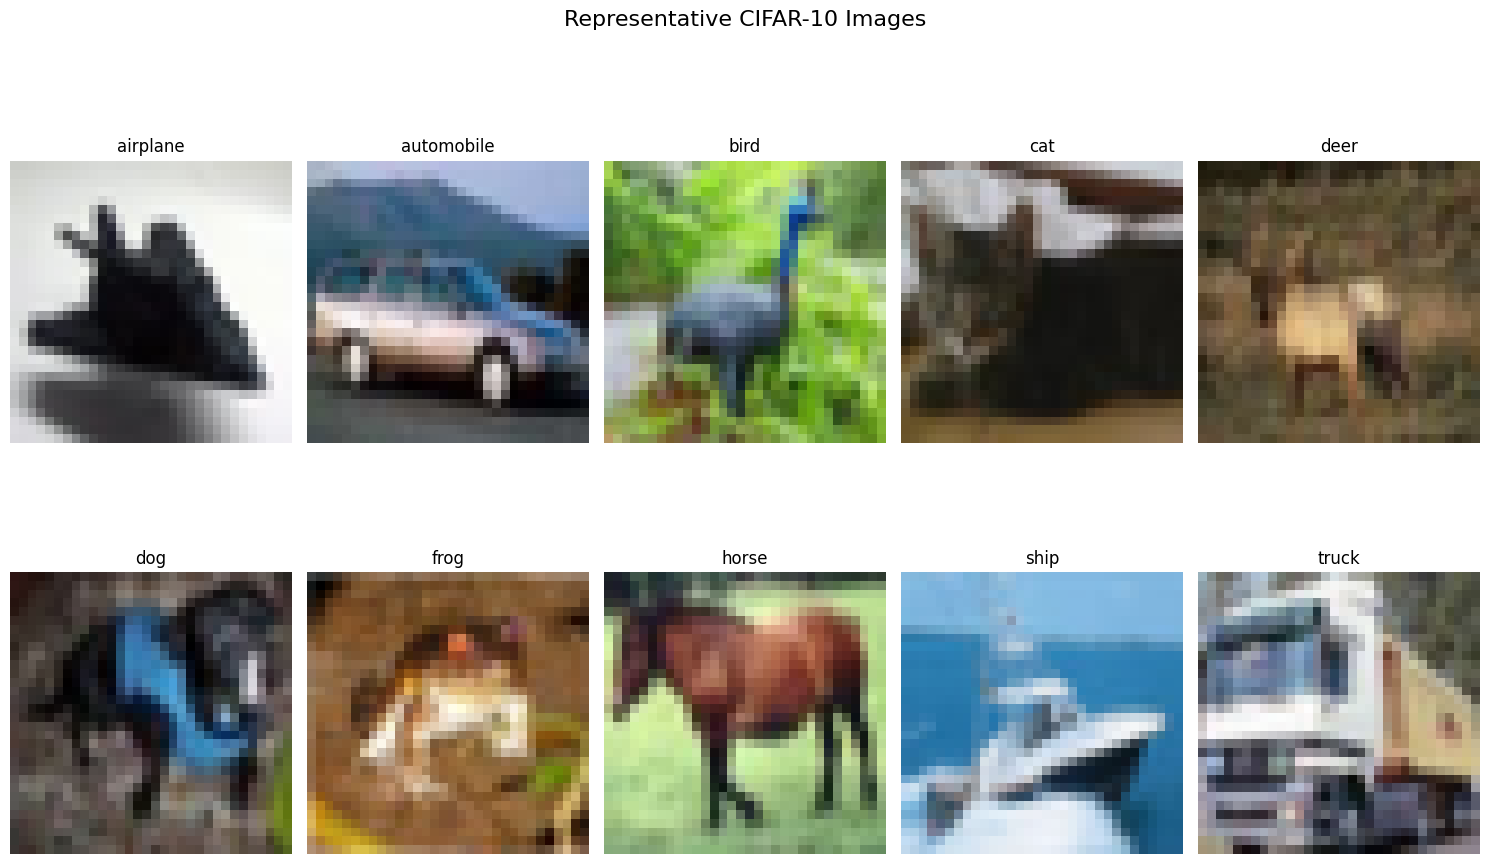

In [ ]:
CLASS_NAMES = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

plt.figure(figsize=(15, 10))

for class_id in range(10):

    index = np.where(labels == class_id)[0][0]

    plt.subplot(2, 5, class_id + 1)
    plt.imshow(images[index])
    plt.title(CLASS_NAMES[class_id])
    plt.axis("off")

plt.suptitle("Representative CIFAR-10 Images", fontsize=16)

plt.tight_layout()
plt.show()

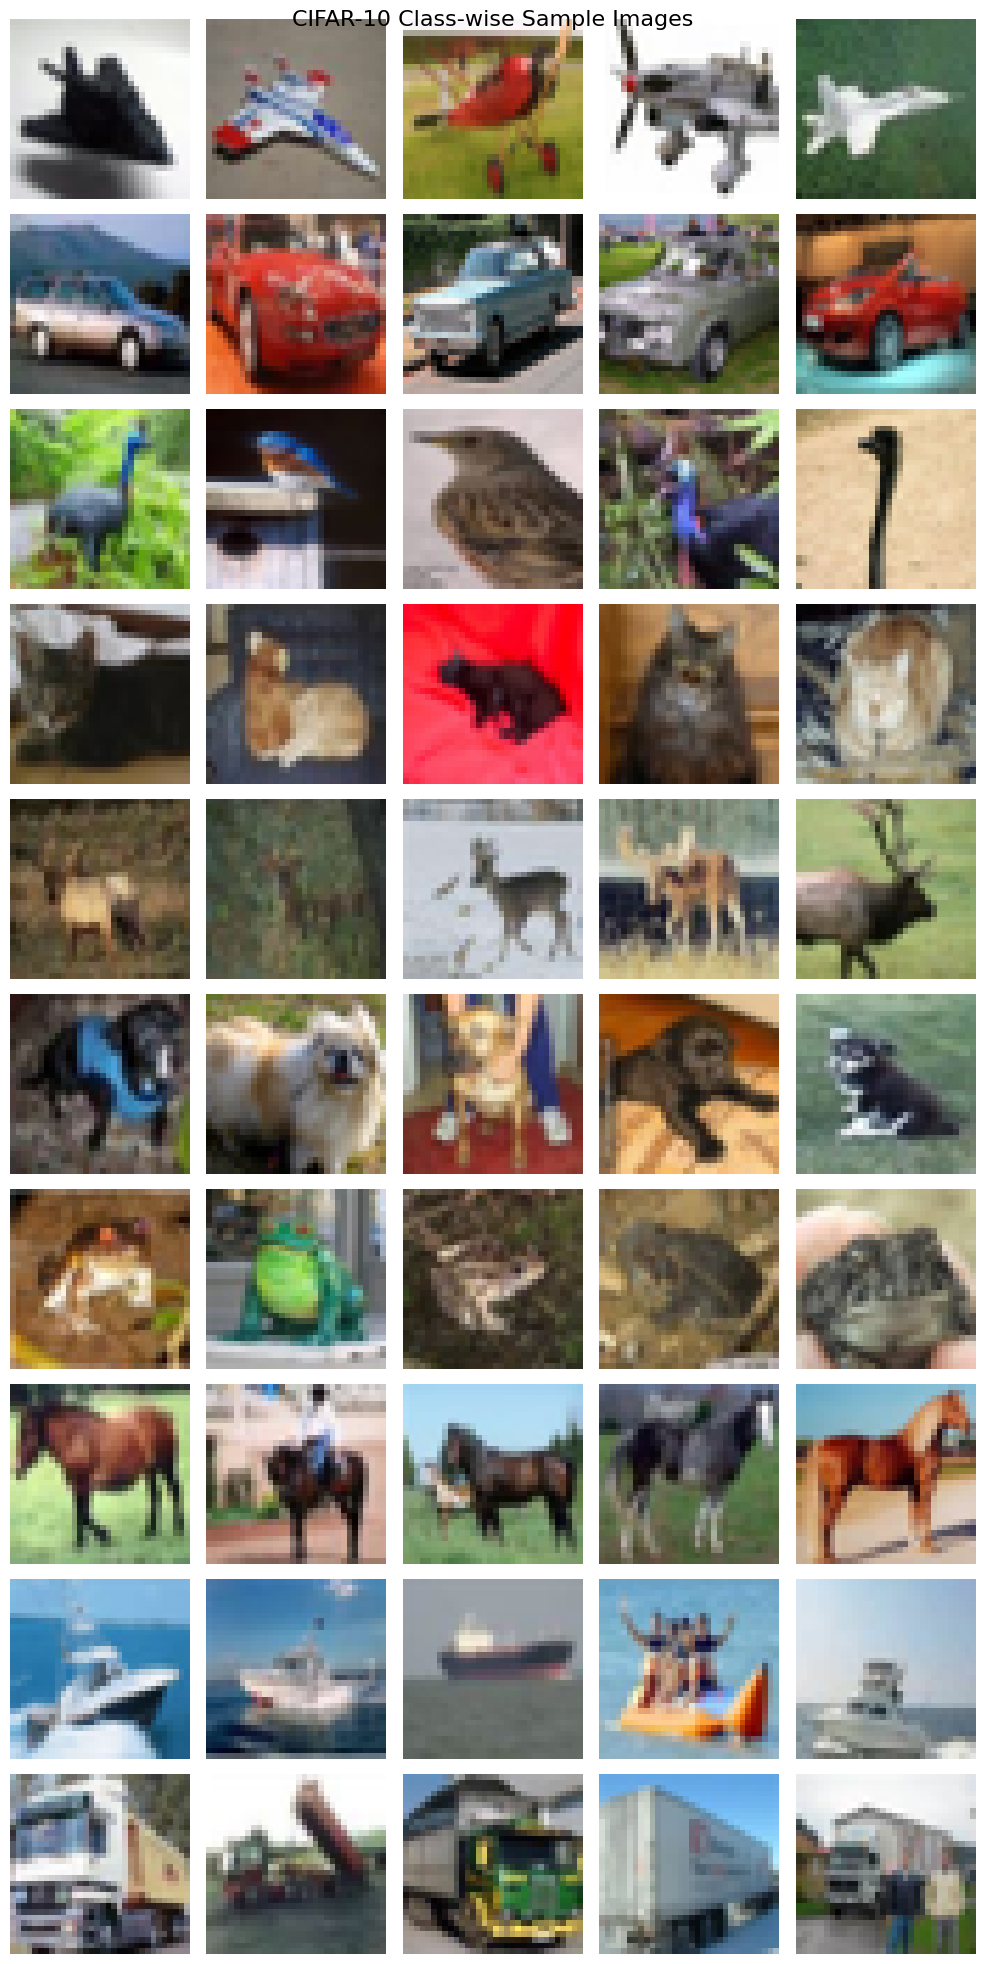

In [ ]:
fig, axes = plt.subplots(
    10,
    5,
    figsize=(10, 20)
)

for class_id in range(10):

    indices = np.where(labels == class_id)[0][:5]

    for column, index in enumerate(indices):

        axes[class_id, column].imshow(images[index])
        axes[class_id, column].axis("off")

        if column == 0:
            axes[class_id, column].set_ylabel(
                CLASS_NAMES[class_id],
                fontsize=10
            )

plt.suptitle(
    "CIFAR-10 Class-wise Sample Images",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [ ]:
image_stats = calculate_image_statistics(
    images,
    labels
)

image_stats.head()

,label,class_name,brightness,contrast,red_mean,green_mean,blue_mean
0,6,frog,103.447266,51.973717,141.205078,105.099609,64.037109
1,9,truck,130.347336,60.479198,130.199219,130.365234,130.477539
2,9,truck,133.740555,82.563248,133.484375,135.152344,132.584961
3,4,deer,80.224281,36.471916,99.979492,83.279297,57.414062
4,1,automobile,103.474937,60.549606,92.021484,102.400391,116.002930


In [ ]:
summary = summary_statistics(image_stats)

summary

,count,mean,std,min,25%,50%,75%,max
brightness,50000.0,120.707558,31.942949,7.883789,99.402016,118.897137,139.832436,252.296875
contrast,50000.0,53.817570,14.091622,9.625605,43.768087,53.425646,63.331769,114.991783
red_mean,50000.0,125.306923,32.731384,2.547852,103.862793,124.142578,145.414795,252.180664
green_mean,50000.0,122.950394,32.075745,3.529297,101.887207,121.772949,142.419434,252.627930
blue_mean,50000.0,113.865379,39.096313,3.208008,86.325928,111.061523,138.565674,252.812500


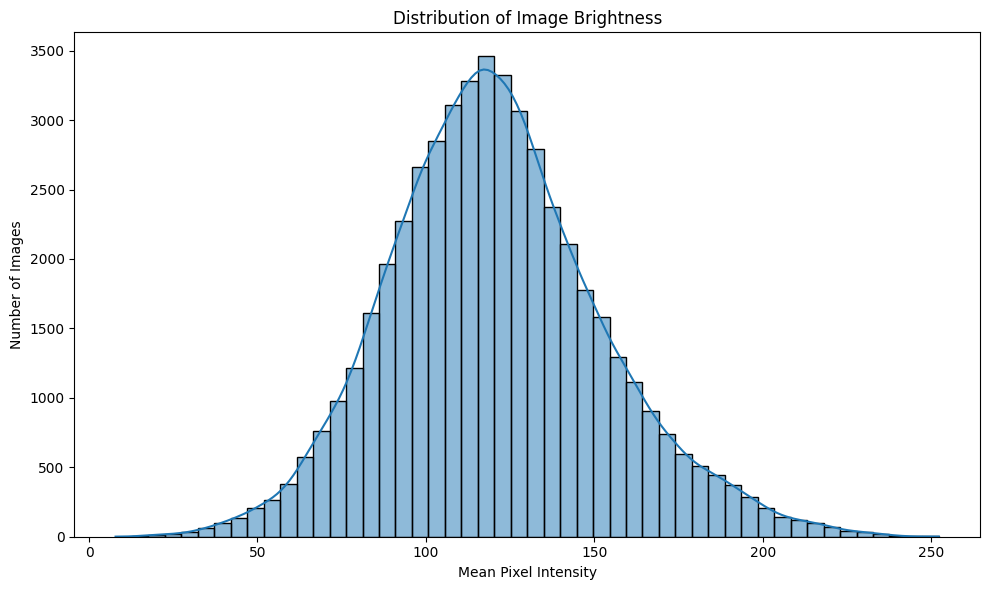

In [ ]:
plt.figure(figsize=(10, 6))

sns.histplot(
    image_stats["brightness"],
    bins=50,
    kde=True
)

plt.title("Distribution of Image Brightness")
plt.xlabel("Mean Pixel Intensity")
plt.ylabel("Number of Images")

plt.tight_layout()
plt.show()

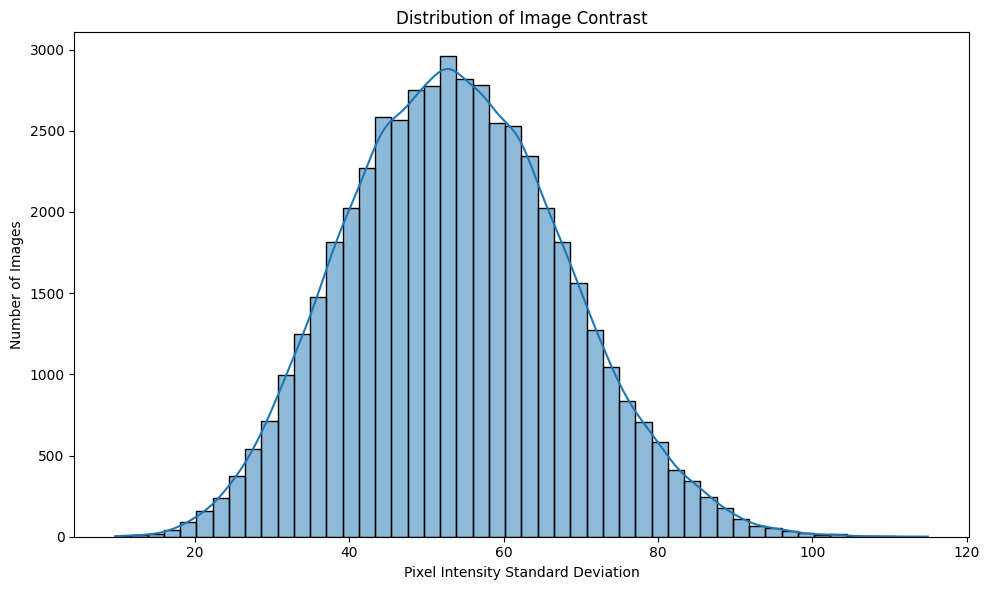

In [ ]:
plt.figure(figsize=(10, 6))

sns.histplot(
    image_stats["contrast"],
    bins=50,
    kde=True
)

plt.title("Distribution of Image Contrast")
plt.xlabel("Pixel Intensity Standard Deviation")
plt.ylabel("Number of Images")

plt.tight_layout()
plt.show()

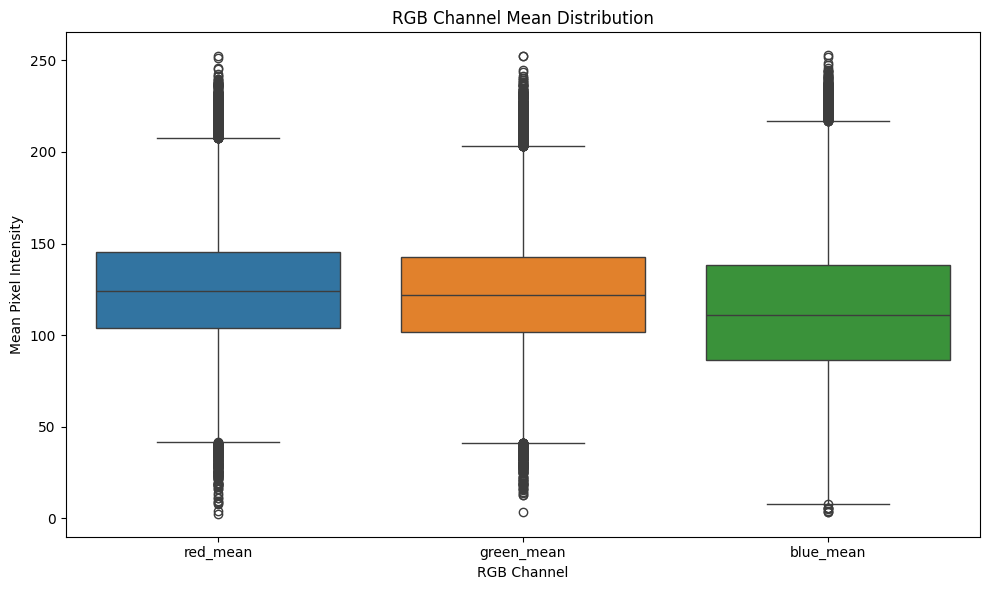

In [ ]:
rgb_data = image_stats[
    [
        "red_mean",
        "green_mean",
        "blue_mean"
    ]
]

plt.figure(figsize=(10, 6))

sns.boxplot(data=rgb_data)

plt.title("RGB Channel Mean Distribution")
plt.xlabel("RGB Channel")
plt.ylabel("Mean Pixel Intensity")

plt.tight_layout()
plt.show()

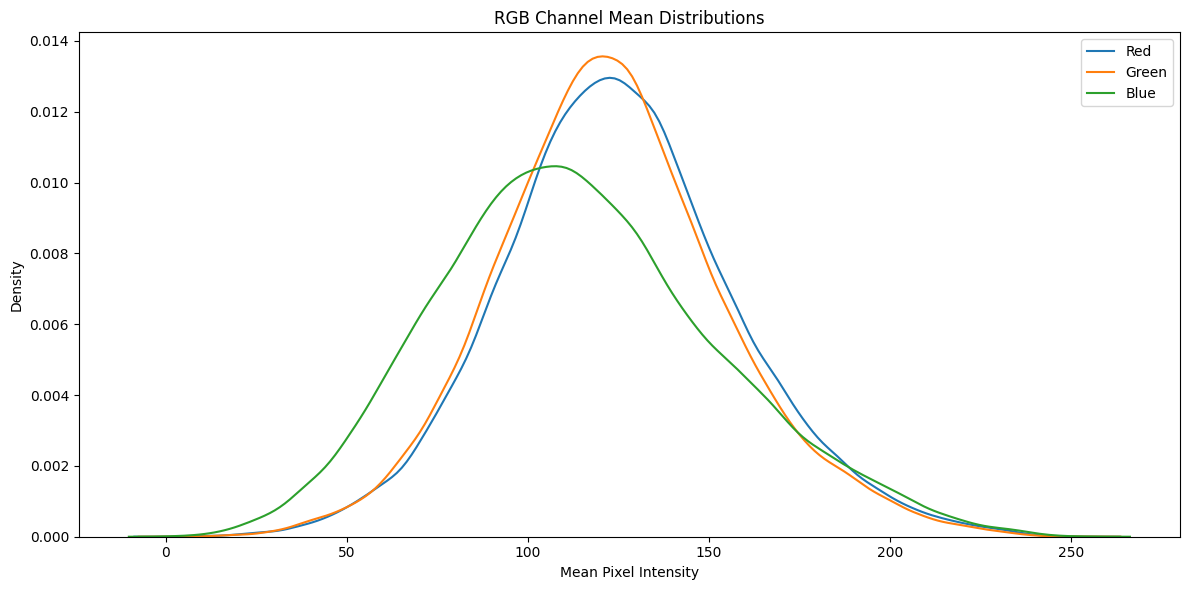

In [ ]:
plt.figure(figsize=(12, 6))

sns.kdeplot(
    image_stats["red_mean"],
    label="Red"
)

sns.kdeplot(
    image_stats["green_mean"],
    label="Green"
)

sns.kdeplot(
    image_stats["blue_mean"],
    label="Blue"
)

plt.title("RGB Channel Mean Distributions")
plt.xlabel("Mean Pixel Intensity")
plt.ylabel("Density")

plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
class_stats = class_statistics(image_stats)

class_stats

brightness                          contrast             \
                  mean      median        std       mean     median   
class_name                                                            
airplane    142.365784  142.175293  35.588505  52.110748  51.457905   
automobile  116.697540  113.002762  30.865509  60.461193  59.829552   
bird        119.405602  117.314453  34.229450  46.488453  45.004494   
cat         116.231827  115.077469  32.768757  55.296425  54.662582   
deer        111.775299  110.812332  28.190548  45.602520  44.137367   
dog         117.394234  115.929367  28.740019  55.386330  54.877563   
frog        106.561935  104.083496  31.066114  47.743111  46.088867   
horse       118.890198  118.873535  26.256636  56.402126  55.734238   
ship        133.476028  133.266602  28.638420  55.062462  54.775505   
truck       124.277214  122.598145  25.851456  63.622318  63.607841   

                         red_mean                         green_mean  \
                  std        mean      median        std        mean   
class_name                                                             
airplane    14.467275  134.042130  133.530762  39.235249  142.883987   
automobile  11.235037  120.151947  117.094238  31.104815  115.904999   
bird        13.800778  124.758728  124.015137  35.802773  125.326637   
cat         13.784749  126.348022  125.929688  34.491997  116.385086   
deer        12.832217  120.255615  119.475098  30.767456  118.627464   
dog         13.148455  127.481102  126.126953  31.045418  118.482376   
frog        12.738153  119.864548  118.576172  33.279953  111.790390   
horse       12.567261  127.999390  128.228027  27.979239  122.365273   
ship        13.060093  125.007614  123.788086  31.801264  133.975632   
truck       11.293801  127.160072  125.249023  27.382713  123.762085   

                                    blue_mean                         
                median        std        mean      median        std  
class_name                                                            
airplane    142.988770  36.146435  150.171234  152.560547  41.816467  
automobile  112.931641  31.804968  114.035652  111.308105  35.322300  
bird        124.435059  34.067581  108.131424  102.146484  41.109703  
cat         115.522461  33.468967  105.962349  103.791016  35.849537  
deer        118.561035  28.298513   96.442825   93.275879  33.455086  
dog         118.152832  29.317587  106.219238  104.499023  31.738253  
frog        110.104004  31.444120   88.030861   83.823730  34.668659  
horse       123.061523  26.777334  106.305923  104.956055  29.270330  
ship        133.999023  29.044954  141.444839  142.260742  31.071016  
truck       122.276855  26.460390  121.909477  121.045410  28.979271

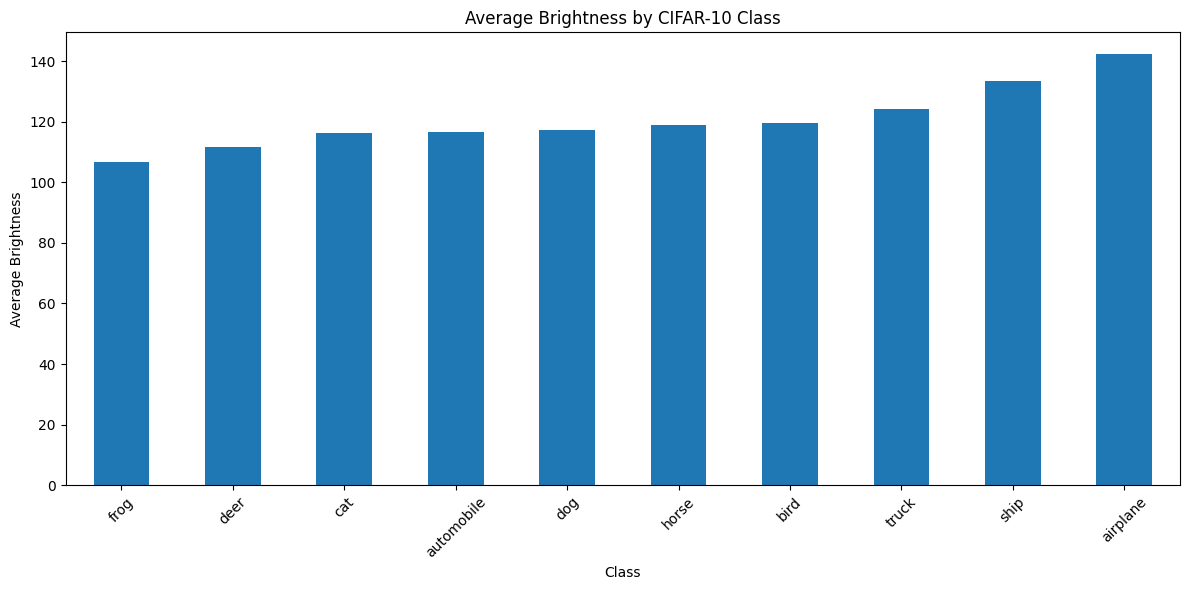

In [ ]:
class_brightness = (
    image_stats
    .groupby("class_name")["brightness"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(12, 6))

class_brightness.plot(kind="bar")

plt.title("Average Brightness by CIFAR-10 Class")
plt.xlabel("Class")
plt.ylabel("Average Brightness")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

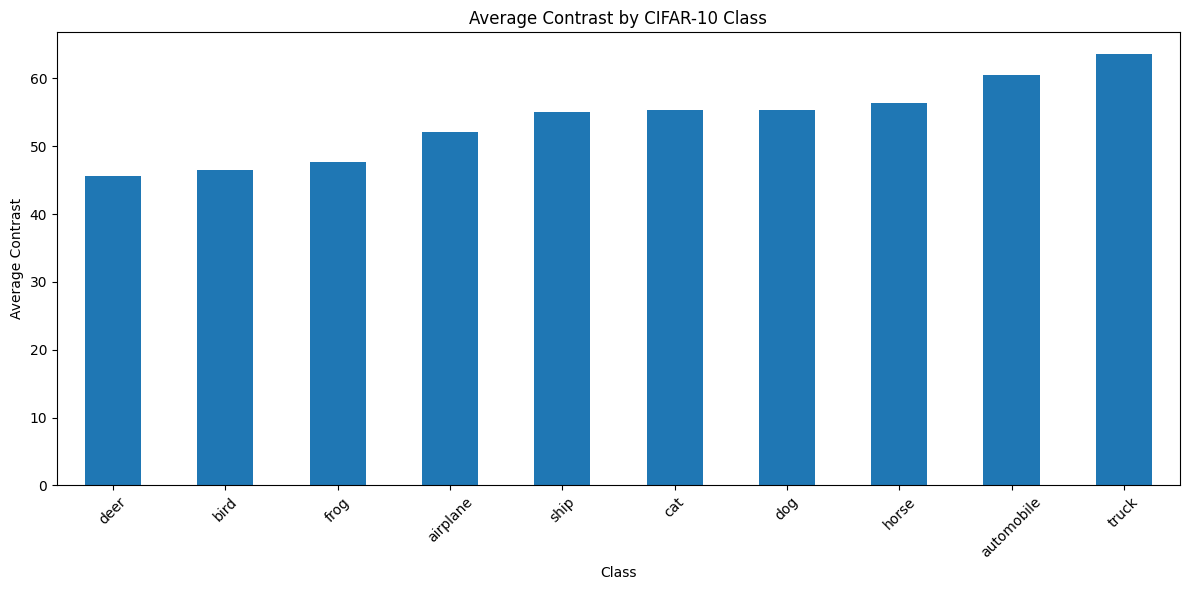

In [ ]:
class_contrast = (
    image_stats
    .groupby("class_name")["contrast"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(12, 6))

class_contrast.plot(kind="bar")

plt.title("Average Contrast by CIFAR-10 Class")
plt.xlabel("Class")
plt.ylabel("Average Contrast")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
skewness = calculate_skewness(image_stats)

skewness

,skewness
brightness,0.316415
contrast,0.176257
red_mean,0.189560
green_mean,0.225072
blue_mean,0.335753


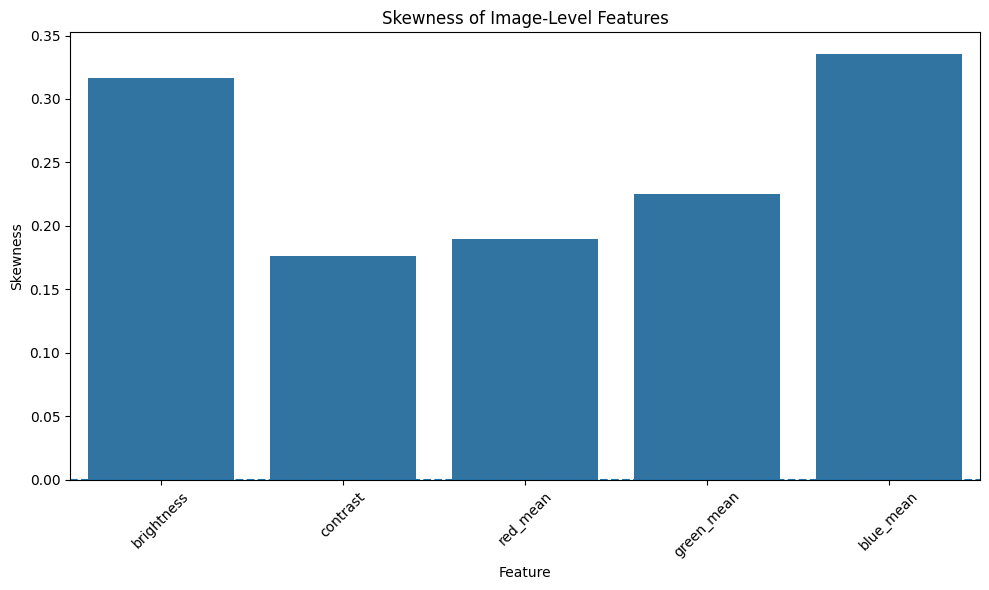

In [ ]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=skewness.index,
    y=skewness["skewness"]
)

plt.axhline(
    0,
    linestyle="--"
)

plt.title("Skewness of Image-Level Features")
plt.xlabel("Feature")
plt.ylabel("Skewness")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Anomaly Detection

Image-level statistical features are analyzed to identify potentially
unusual observations. The Interquartile Range (IQR) method is used to
identify observations outside the typical distribution of brightness,
contrast, and RGB channel statistics.

These observations are treated as statistical anomalies and are not
automatically considered incorrect or corrupted images.